# Analysis test

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from wavelet_utils import loadFilterParamDict
from analysis_utils import correctNeuronPos, repetability_trial3, PearsonCorrelationRF_batched

In [2]:
spks_path = r"D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0409_zebra5\ZEBRA_ANALYSIS\resps_all.npy"
resolution = 2.14 # um/px

temppath = r'D:\SynologyDriveSyncedDATA\PROCESSED\Waven'

dwt_path = Path(temppath) / r"zebra_s0_d420.0_fps59.94_RESAMPLED13fps_downscaled_lib40_26_8_5_4_4_100_66dwt.npy"

libpath= Path(temppath) / 'gaborLibrary_40_26_8_5_4_4.npy'
paramspath = libpath.with_suffix('.json')   

In [3]:
xs, ys, angles, sizes, freqs, phases, visual_coverage, full_screen_coverage, screen_x, screen_y = loadFilterParamDict(paramspath)

## Load data

In [4]:
spks=np.load(spks_path)
print(f"spks shape: {spks.shape}")
parent_dir = Path(spks_path).parent
neuron_pos=np.load(parent_dir / 'component_centers.npy')

## converts neuron position in microns
neuron_pos=correctNeuronPos(neuron_pos, resolution)
print(f"neuron_pos shape: {neuron_pos.shape}")

spks shape: (5, 5460, 2254)
neuron_pos shape: (2254, 2)


In [5]:
respcorr = repetability_trial3(spks)


In [6]:
# top 3 most repeatable neurons
top_neurons = np.argsort(respcorr)[-3:]
print(f"Top 3 most repeatable neurons: {top_neurons}")

Top 3 most repeatable neurons: [2119 2188 1820]


## Correlate neural data with decomposed stimulus

In [ ]:
## runs correlation analysis

dwt = np.load(dwt_path)
print(f"dwt shape: {dwt.shape}")

mean_spks = np.mean(spks[:, :, :], axis=0)

# restrict dwt to >0
#dwt[dwt < 0] = 0

dwt=np.abs(dwt)

rfs = PearsonCorrelationRF_batched(dwt, mean_spks)

n_neurons = rfs.shape[0]

dwt shape: (5460, 40, 26, 8, 5, 4, 4)
    stim_flat shape: (5460, 665600) (n_timepoints=5460, n_features=665600)
    resp shape: (5460, 2254) (n_timepoints=5460, n_neurons=2254)
    Torch using: cuda, GPU index: 0, GPU name: NVIDIA GeForce RTX 4070 SUPER


Pearson RF feature batches: 100%|██████████| 67/67 [00:08<00:00,  7.56it/s]


| Torch (cuda:0) tensor memory usage:
| ------------------------------------------------------------
| R                   :    46.95 MB  | shape=(2254, 5460)  dtype=torch.float32
| S_chunk             :   116.64 MB  | shape=(5600, 5460)  dtype=torch.float32
| rfs_chunk           :    48.15 MB  | shape=(2254, 5600)  dtype=torch.float32
| ------------------------------------------------------------
| TENSORS:   211.74 MB (  1.7%) | RESERVED:   938.00 MB (  7.6%) | TOTAL GPU: 12281.50 MB  
    output shape: (2254, 40, 26, 8, 5, 4, 4) (neurons=2254, feature_dims=(40, 26, 8, 5, 4, 4))


In [8]:
# find absolut maximum RF value across all neurons and features
max_idx = np.unravel_index(np.argmax(rfs), rfs.shape)
max_idx = tuple(int(i) for i in max_idx)
max_value = rfs[max_idx]
print(f"max RF value: {max_value} at index {max_idx}")

max RF value: 0.2423342615365982 at index (205, 5, 25, 5, 4, 3, 1)


In [9]:
# find maximum RF value for each neuron
max_values = []
for my_neuron in range(n_neurons):
    myrfs = rfs[my_neuron]
    max_idx = np.unravel_index(np.argmax(myrfs), myrfs.shape)
    max_idx = tuple(int(i) for i in max_idx)
    max_value = myrfs[max_idx]
    max_values.append(max_value)
    #print(f"Neuron {my_neuron} max RF value: {max_value:.3f} at index {max_idx}, respcorr: {respcorr[my_neuron]:.3f}")



In [10]:
# save respcorr and max_values for each neuron to a csv file
import pandas as pd
df = pd.DataFrame({'respcorr': respcorr, 'max_values': max_values})
df.to_csv(parent_dir / 'respcorr_max_values.csv', index=False)

In [11]:
parent_dir

WindowsPath('D:/SynologyDriveSyncedDATA/PROCESSED/GBM/GBM11/g11_0409_zebra5/ZEBRA_ANALYSIS')

In [12]:
my_neuron = 2188
my_neuron = 2119
my_neuron = 1820
my_neuron = 2097
my_neuron = 456 # RF value: 0.105 at index (5, 6, 2, 4, 3, 1), respcorr: 0.707 - tényleg - fekete folt
#my_neuron = 1813 # RF value: 0.116 at index (7, 7, 3, 4, 0, 2), respcorr: 0.620 - tényleg - csikok

myrfs = rfs[my_neuron]
max_idx = np.unravel_index(np.argmax(myrfs), myrfs.shape)
max_idx = tuple(int(i) for i in max_idx)
max_value = myrfs[max_idx]
print(f"Neuron {my_neuron} max RF value: {max_value:.3f} at index {max_idx}, respcorr: {respcorr[my_neuron]:.3f}")

Neuron 456 max RF value: 0.204 at index (25, 23, 5, 3, 3, 3), respcorr: 0.707


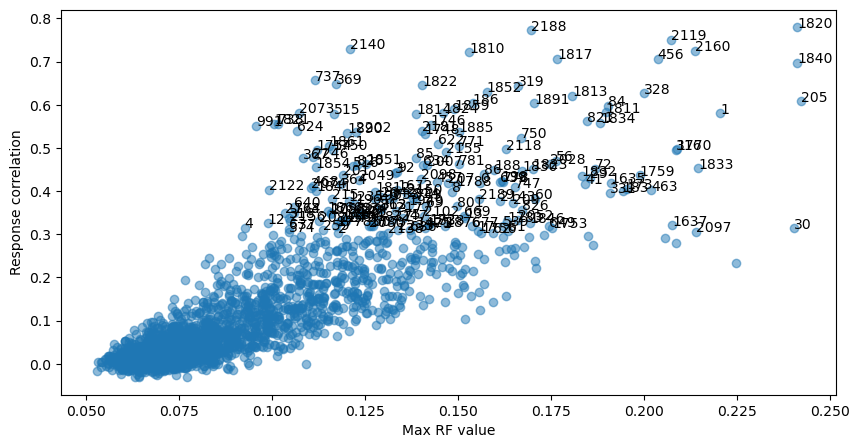

In [13]:
# plot max_values vs respcorr with data labels
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.scatter(max_values, respcorr, alpha=0.5)

for i in range(n_neurons):
    if respcorr[i] > 0.3 and max_values[i] > 0.09: # only label neurons with high repeatability
        plt.annotate(f"{i}", (max_values[i], respcorr[i]))

plt.xlabel('Max RF value')
plt.ylabel('Response correlation')
plt.show()


## Visualization

In [14]:
#libpath= Path(temppath) / 'gaborLibrary_5_3_8_5_4_4.npy'
#libpath= Path(temppath) / 'gaborLibrary_15_10_8_5_4_4.npy'
libpath= Path(temppath) / 'gaborLibrary_40_26_8_5_4_4.npy'
library = np.load(libpath)

downsampled_video_path = r"D:\SynologyDriveSyncedDATA\PROCESSED\Waven\zebra_s0_d420.0_fps59.94_RESAMPLED13fps_downscaled.npy"
downsampled_video=np.load(downsampled_video_path)
WT=dwt

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

az_left, az_right, el_bottom, el_top = visual_coverage

param_names = ["x", "y", "angle", "size", "freq", "phase"]
param_values = [xs, ys, angles, sizes, freqs, phases]

resp = mean_spks

n_frames = min(downsampled_video.shape[0], WT.shape[0], resp.shape[0])
n_neurons = resp.shape[1]

slider_width = "300px"

sliders = [
    widgets.IntSlider(
        value=len(vals) // 2,
        min=0,
        max=len(vals) - 1,
        step=1,
        description=name,
        continuous_update=False,
        layout=widgets.Layout(width=slider_width)
    )
    for name, vals in zip(param_names, param_values)
]

time_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=n_frames - 1,
    step=1,
    description="frame",
    continuous_update=False,
    layout=widgets.Layout(width="100%")
)

neuron_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=n_neurons - 1,
    step=1,
    description="neuron",
    continuous_update=False,
    layout=widgets.Layout(width=slider_width)
)

out_rfs = widgets.Output()
out_time = widgets.Output()
out_overlay = widgets.Output()

def plot_view(*args):
    xi, yi, anglei, sizei, freqi, phasei = [s.value for s in sliders]
    ti = time_slider.value
    ni = neuron_slider.value

    frame = downsampled_video[ti]
    filt = library[xi, yi, anglei, sizei, freqi, phasei, :, :]

    transient = WT[:n_frames, xi, yi, anglei, sizei, freqi, phasei]
    neuron_trace = resp[:n_frames, ni]

    current_rfs = rfs[ni, xi, yi, anglei, sizei, freqi, phasei]
    current_respcorr = respcorr[ni]

    title_params = (
        f"frame={ti}, neuron={ni}, respcorr={current_respcorr:.4f}, "
        f"rfs={current_rfs:.4f}\n"
        f"x={xs[xi]:.2f}, y={ys[yi]:.2f}, "
        f"angle={angles[anglei]:.2f}, "
        f"size={sizes[sizei]:.2f}, "
        f"freq={freqs[freqi]:.3f}, "
        f"phase={phases[phasei]:.2f}"
    )

    with out_rfs:
        out_rfs.clear_output(wait=True)

        fig, axes = plt.subplots(2, 3, figsize=(9, 5))
        axes = axes.flat

        cross_sections = [
            ("x", xs, rfs[ni, :, yi, anglei, sizei, freqi, phasei], xi),
            ("y", ys, rfs[ni, xi, :, anglei, sizei, freqi, phasei], yi),
            ("angle", angles, rfs[ni, xi, yi, :, sizei, freqi, phasei], anglei),
            ("size", sizes, rfs[ni, xi, yi, anglei, :, freqi, phasei], sizei),
            ("freq", freqs, rfs[ni, xi, yi, anglei, sizei, :, phasei], freqi),
            ("phase", phases, rfs[ni, xi, yi, anglei, sizei, freqi, :], phasei),
        ]

        for ax, (name, vals, data, idx) in zip(axes, cross_sections):
            ax.plot(vals, data, marker="o")
            ax.axvline(vals[idx], color="red", linestyle="--", linewidth=1.5)
            ax.axhline(0, color="black", linewidth=0.5)
            ax.set_title(f"{name} | rfs={data[idx]:.4f}", fontsize=9)
            ax.set_xlabel(name)
            ax.set_ylabel("rfs")

        fig.suptitle(f"RFS cross-sections — neuron {ni}", fontsize=11)
        plt.tight_layout()
        plt.show()

    with out_time:
        out_time.clear_output(wait=True)

        z0 = max(0, ti - 12)
        z1 = min(n_frames, ti + 13)
        t_zoom = np.arange(z0, z1)

        fig, (ax_zoom, ax_full) = plt.subplots(
            1, 2,
            figsize=(14, 3.5),
            gridspec_kw={"width_ratios": [1, 2]}
        )

        ax_full.plot(np.arange(n_frames), transient)
        ax_full.axvline(ti, color="red", linestyle="--", linewidth=2)
        ax_full.set_xlim(0, n_frames - 1)
        ax_full.set_xlabel("Frame")
        ax_full.set_title(
            f"WT + neuron transient — full | neuron={ni}, respcorr={current_respcorr:.4f}"
        )

        ax_full_r = ax_full.twinx()
        ax_full_r.plot(np.arange(n_frames), neuron_trace, color="orange", alpha=0.8)
        ax_full_r.set_ylabel("Neuron response")

        wt_ylim = ax_full.get_ylim()
        neuron_ylim = ax_full_r.get_ylim()

        ax_zoom.plot(t_zoom, transient[z0:z1], marker="o")
        ax_zoom.axvline(ti, color="red", linestyle="--", linewidth=2)
        ax_zoom.set_xlim(z0, z1 - 1)
        ax_zoom.set_ylim(wt_ylim)
        ax_zoom.set_title("Zoom ±12 frames")
        ax_zoom.set_xlabel("Frame")
        ax_zoom.set_ylabel("WT response")

        ax_zoom_r = ax_zoom.twinx()
        ax_zoom_r.plot(t_zoom, neuron_trace[z0:z1], color="orange", marker=".")
        ax_zoom_r.set_ylim(neuron_ylim)

        ax_zoom_r.set_yticks([])
        ax_zoom_r.set_ylabel("")
        ax_zoom_r.spines["right"].set_visible(False)

        ax_full.set_yticks([])
        ax_full.set_ylabel("")
        ax_full.spines["left"].set_visible(False)

        plt.tight_layout()
        plt.show()

    with out_overlay:
        out_overlay.clear_output(wait=True)

        fig, ax = plt.subplots(figsize=(7, 5))

        ax.imshow(
            frame.T,
            cmap="gray",
            extent=[az_left, az_right, el_bottom, el_top],
            origin="lower",
            aspect="auto",
        )

        filt_plot = filt.T
        v = np.max(np.abs(filt_plot))
        if v == 0:
            v = 1

        rgba = np.zeros((*filt_plot.shape, 4), dtype=float)
        pos = filt_plot > 0
        neg = filt_plot < 0

        rgba[pos, 0] = 1.0
        rgba[neg, 1] = 1.0
        rgba[..., 3] = np.abs(filt_plot) / v * 0.7

        ax.imshow(
            rgba,
            extent=[az_left, az_right, el_bottom, el_top],
            origin="lower",
            aspect="auto",
        )

        ax.set_title("Video + selected Gabor overlay\n" + title_params)
        ax.set_xlabel("Azimuth (°)")
        ax.set_ylabel("Elevation (°)")

        plt.tight_layout()
        plt.show()

for s in sliders + [time_slider, neuron_slider]:
    s.observe(plot_view, names="value")

slider_box = widgets.VBox([neuron_slider] + sliders)
top_row = widgets.HBox([slider_box, out_rfs])

display(top_row, out_time, time_slider, out_overlay)

plot_view()

Output()

IntSlider(value=0, continuous_update=False, description='frame', layout=Layout(width='100%'), max=5459)

Output()

In [16]:
def ize():
    
        # Remove near-perfect correlations (artifacts)
    all_correlations = all_correlations - (all_correlations >= 0.99).astype('float16')
    all_correlations = np.nan_to_num(all_correlations)
    
    # rfs = rfs[:, :, :, :-1, :]
    # rfssum = rfs.sum(axis=4)

    indices = []
    maxes = []
    for i in range(rfs.shape[0]):
        idx, m = max_by_index(i, abs(rfs))
        indices.append([idx[0][0], idx[1][0], idx[2][0], idx[3][0]])#,  idx[4][0]])
        maxes.append(m)

    indices = np.array(indices)
    # maxes=np.array(maxes)
    xmax = indices[:, 0]
    ymax = indices[:, 1]
    omax = indices[:, 2]
    smax = indices[:, 3]
    # dmax = indices[:, 4]
    maxe=[xmax, ymax, omax, smax]#, dmax]
    xM, xm,yM, ym=visual_coverage
    omax_corr=orientation_correction_for_stretches(visual_coverage, nx, ny, omax*22.5)
    xmax_corr=(abs(xmax)*(abs(xm-xM)/nx))+xM
    #ymax_corr = (abs(ymax-ny) * (abs(yM - ym) / ny)) + ym
    ymax_corr = (ymax * (abs(yM - ym) / ny)) + ym
    print(sigmas)
    smax_corr=sigmas[smax.astype(int)]
    maxe_corr=[xmax_corr, ymax_corr, omax_corr, smax_corr]
    
    
    torch.cuda.empty_cache()
    
    if plotting:

        if np.sum(fil)==0:
            plt.figure()
            plt.rcParams['axes.facecolor']='none'
            plt.scatter(neuron_pos[:, 1], neuron_pos[:, 0], s=5, c=xmax_corr, cmap='jet')
            plt.colorbar()
            plt.title('azimuth (visual degree)')
            plt.xlabel('position x (um)')
            plt.ylabel('position y (um)')

            plt.figure()
            plt.rcParams['axes.facecolor'] = 'none'
            plt.scatter(neuron_pos[:, 1], neuron_pos[:, 0], s=5, c=ymax_corr, cmap='jet')
            plt.colorbar()
            plt.title('elevation (visual degree)')
            plt.xlabel('position x (um)')
            plt.ylabel('position y (um)')

            plt.figure()
            plt.rcParams['axes.facecolor'] = 'none'
            plt.scatter(neuron_pos[:, 1], neuron_pos[:, 0], s=5, c=omax_corr, vmax=180, cmap='hsv')
            plt.colorbar()
            plt.title('orientation (degree)')
            plt.xlabel('position x (um)')
            plt.ylabel('position y (um)')

            plt.figure()
            plt.rcParams['axes.facecolor'] = 'none'
            plt.scatter(neuron_pos[:, 1], neuron_pos[:, 0], s=5, c=smax_corr, cmap='coolwarm')
            plt.colorbar()
            plt.title('size (visual degree)')
            plt.xlabel('position x (um)')
            plt.ylabel('position y (um)')

            plt.figure()
            plt.imshow(np.ones((68, 180)), cmap='Greys')
            plt.plot([0, 175], [32, 32], 'k--')
            plt.plot([175, 175], [2, 66], 'k--')
            plt.xticks([0, 135, 179], [135, 0, -45])
            plt.yticks([0, 34, 67], [34, 0, -34])
            plt.axis('image')
            plt.xlabel('Azimuth')
            plt.ylabel('Elevation')
            plt.title('Screen positions')


        else:
            fil=maxes>0.2
            print('filtering')
            plt.figure()
            plt.scatter(neuron_pos[fil, 1], neuron_pos[fil, 0], s=5, c=xmax[fil], cmap='jet_r')
            plt.colorbar()
            plt.title('xmax')

            plt.figure()
            plt.scatter(neuron_pos[fil, 1], neuron_pos[fil, 0], s=5, c=ymax[fil], cmap='jet_r')
            plt.colorbar()
            plt.title('ymax')

            plt.figure()
            plt.scatter(neuron_pos[fil, 1], neuron_pos[fil, 0], s=5, c=omax[fil], cmap='jet_r')
            plt.colorbar()
  
    return rfs, maxe,maxe_corr, maxes